# 06 Semantic Maps of LLM-Generated Texts

## Objective

I examine whether LLM-generated texts form visible clusters in semantic embedding space.

The previous exploratory analysis focused on stylometric features such as sentence length, punctuation, lexical diversity, function-word usage, and readability. This notebook takes a different perspective: instead of analyzing handcrafted writing-style features, I represent each generated text using sentence embeddings and project those embeddings into two-dimensional semantic maps.

## Research Question

Can model-generated texts be distinguished by their semantic embedding patterns?

## Purpose of this notebook

This notebook investigates whether generated texts cluster by:

- model family;
- genre;
- theme.

The main goal is to compare semantic clustering with stylometric results. If model families do not separate strongly in embedding space but do differ strongly in stylometric space, that suggests model identity is more visible in writing style than in general semantic content.

In [13]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

EMBEDDING_PATH = PROJECT_ROOT / "data" / "features" / "final" / "text_embeddings.npy"
METADATA_PATH = PROJECT_ROOT / "data" / "features" / "final" / "text_embedding_metadata.csv"

PCA_PATH = PROJECT_ROOT / "outputs" / "semantic_maps" / "pca_coordinates.csv"
TSNE_PATH = PROJECT_ROOT / "outputs" / "semantic_maps" / "tsne_coordinates.csv"
SILHOUETTE_PATH = PROJECT_ROOT / "outputs" / "semantic_maps" / "embedding_silhouette_scores.csv"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("Project root:", PROJECT_ROOT)
print("Embedding path:", EMBEDDING_PATH)
print("Metadata path:", METADATA_PATH)
print("PCA path:", PCA_PATH)
print("t-SNE path:", TSNE_PATH)
print("Silhouette path:", SILHOUETTE_PATH)

Project root: /Users/violaawor/Desktop/LLM-sytlometric
Embedding path: /Users/violaawor/Desktop/LLM-sytlometric/data/features/final/text_embeddings.npy
Metadata path: /Users/violaawor/Desktop/LLM-sytlometric/data/features/final/text_embedding_metadata.csv
PCA path: /Users/violaawor/Desktop/LLM-sytlometric/outputs/semantic_maps/pca_coordinates.csv
t-SNE path: /Users/violaawor/Desktop/LLM-sytlometric/outputs/semantic_maps/tsne_coordinates.csv
Silhouette path: /Users/violaawor/Desktop/LLM-sytlometric/outputs/semantic_maps/embedding_silhouette_scores.csv


## 1. Load semantic mapping outputs

The semantic mapping files were created by the modular script:

```bash
python scripts/create_semantic_maps.py

In [14]:



## Cell 4 — Code: Load outputs


embeddings = np.load(EMBEDDING_PATH)
metadata_df = pd.read_csv(METADATA_PATH)
pca_df = pd.read_csv(PCA_PATH)
tsne_df = pd.read_csv(TSNE_PATH)
silhouette_df = pd.read_csv(SILHOUETTE_PATH)

print("Embedding matrix shape:", embeddings.shape)
print("Metadata shape:", metadata_df.shape)
print("PCA coordinate shape:", pca_df.shape)
print("t-SNE coordinate shape:", tsne_df.shape)
print("Silhouette score shape:", silhouette_df.shape)

display(metadata_df.head())
display(silhouette_df)

Embedding matrix shape: (1000, 384)
Metadata shape: (1000, 9)
PCA coordinate shape: (1000, 13)
t-SNE coordinate shape: (1000, 11)
Silhouette score shape: (3, 3)


,text_id,prompt_id,genre,theme,model_family,model_name,provider,clean_word_count,clean_length_status
0,GPT_gpt-4o-mini_NAR_001,NAR_001,Narrative,academic,GPT,gpt-4o-mini,OpenAI,217,valid
1,GPT_gpt-4o-mini_NAR_002,NAR_002,Narrative,academic,GPT,gpt-4o-mini,OpenAI,209,valid
2,GPT_gpt-4o-mini_NAR_003,NAR_003,Narrative,academic,GPT,gpt-4o-mini,OpenAI,204,valid
3,GPT_gpt-4o-mini_NAR_004,NAR_004,Narrative,academic,GPT,gpt-4o-mini,OpenAI,207,valid
4,GPT_gpt-4o-mini_NAR_005,NAR_005,Narrative,academic,GPT,gpt-4o-mini,OpenAI,208,valid


,label,n_classes,silhouette_score_cosine
0,model_family,5,-0.007539
1,genre,4,0.036065
2,theme,4,0.068524


### Interpretation

The semantic mapping pipeline successfully produced a complete embedding dataset. The embedding matrix has shape `(1000, 384)`, meaning that all 1,000 generated texts were embedded and each text is represented by a 384-dimensional sentence vector. The metadata table also has 1,000 rows, so every embedding is correctly aligned with its `text_id`, `prompt_id`, `genre`, `theme`, `model_family`, provider information, and word-count metadata.

The PCA coordinate file has 1,000 rows and 13 columns, while the t-SNE coordinate file has 1,000 rows and 11 columns. This confirms that every generated response was projected into two-dimensional visualization space.

The silhouette table already gives the first important result: `theme` has the highest silhouette score, followed by `genre`, while `model_family` is slightly negative. This means that the sentence embeddings are organizing the texts more by semantic content than by the LLM that produced them. This is expected because all models answered the same controlled prompts, so their semantic content is intentionally similar.

## 2. Dataset balance check

Before interpreting semantic maps, I check that the embedding metadata remains balanced across model family and genre. This is important because unbalanced groups could distort the visual interpretation of clustering.

In [15]:
print("Rows by model family:")
display(metadata_df["model_family"].value_counts().sort_index())

print("Rows by genre:")
display(metadata_df["genre"].value_counts().sort_index())

print("Model family × genre:")
display(pd.crosstab(metadata_df["model_family"], metadata_df["genre"]))

Rows by model family:


model_family
Claude      200
DeepSeek    200
GPT         200
Gemini      200
Mistral     200
Name: count, dtype: int64

Rows by genre:


genre
Argumentative    250
Descriptive      250
Dialogue         250
Narrative        250
Name: count, dtype: int64

Model family × genre:


genre,Argumentative,Descriptive,Dialogue,Narrative
model_family,,,,
Claude,50,50,50,50
DeepSeek,50,50,50,50
GPT,50,50,50,50
Gemini,50,50,50,50
Mistral,50,50,50,50


### Interpretation

The semantic mapping dataset remains perfectly balanced. Each model family contributes exactly 200 texts, and each genre contains exactly 250 texts. The cross-tabulation also confirms that each model contributes 50 texts to each genre.

This is important for my analysis because the semantic maps are not distorted by unequal sampling. If one model appeared more often than another, visual clusters might simply reflect sample imbalance. Here, any visible pattern must come from the embedding structure itself rather than from unequal numbers of observations.

This balanced design strengthens the comparison between model-family clustering, genre clustering, and theme clustering.

## 3. Method explanation

### Sentence embeddings

Each generated text is represented using a sentence-transformer embedding model. A sentence embedding converts a full text into a numerical vector that captures broad semantic meaning. Texts with similar meanings should have similar embedding vectors.

In this project, embeddings are useful for testing whether model outputs separate by semantic content, genre, theme, or model family.

### PCA

Principal Component Analysis is a linear dimensionality-reduction method. It projects the high-dimensional embeddings into two dimensions while preserving as much variance as possible.

The PCA map is useful for showing broad global structure.

### t-SNE

t-SNE is a nonlinear dimensionality-reduction method. It is useful for visualizing local neighborhoods and small clusters in high-dimensional data.

The t-SNE map should be interpreted cautiously. It is useful for visualization, but distances and global positions should not be overinterpreted.

### Silhouette score

The silhouette score measures how well observations cluster according to a label. Scores range approximately from -1 to 1:

- values near 1 indicate strong clustering;
- values near 0 indicate weak or overlapping clustering;
- negative values indicate that observations may be closer to other groups than to their assigned group.

In this notebook, I use silhouette scores to compare clustering by `model_family`, `genre`, and `theme`.

In [16]:
def plot_2d_map(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    color_col: str,
    title: str,
    output_filename: str | None = None,
) -> None:
    """
    Plot a two-dimensional semantic map colored by a categorical variable.
    """
    categories = sorted(df[color_col].dropna().astype(str).unique())

    plt.figure(figsize=(9, 7))

    for category in categories:
        subset = df[df[color_col].astype(str) == category]
        plt.scatter(
            subset[x_col],
            subset[y_col],
            label=category,
            alpha=0.70,
            s=28,
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.legend(title=color_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if output_filename is not None:
        output_path = FIGURE_DIR / output_filename
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", output_path)

    plt.show()

## 4. PCA semantic maps

I first inspect PCA maps. PCA gives a broad linear projection of the embedding space. If model families form clearly separated regions, this would suggest that model identity is visible in semantic embedding space.

Saved figure to: /Users/violaawor/Desktop/LLM-sytlometric/outputs/figures/semantic_map_pca_model_family.png


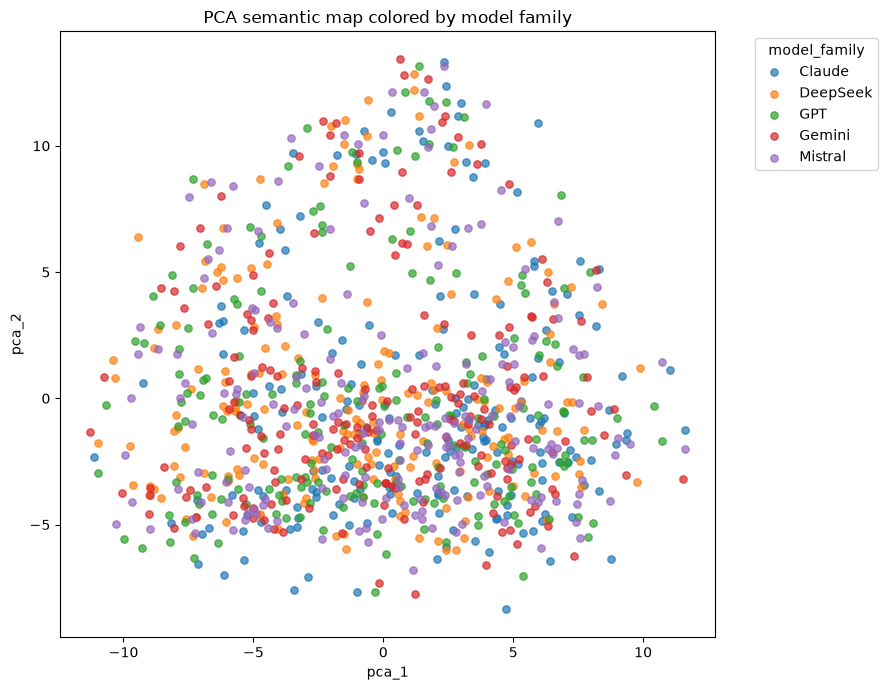

In [17]:
plot_2d_map(
    df=pca_df,
    x_col="pca_1",
    y_col="pca_2",
    color_col="model_family",
    title="PCA semantic map colored by model family",
    output_filename="semantic_map_pca_model_family.png",
)

### Interpretation: PCA by model family

The PCA map colored by model family shows heavy overlap among Claude, DeepSeek, GPT, Gemini, and Mistral. The points from all five models are mixed throughout the same broad PCA space rather than forming model-specific regions.

Visually, no model family separates into an independent cluster. For example, the dense central region contains all five colors, and the upper and side regions also contain a mixture of models. This means that the first two PCA components do not capture a clear model-family signal.

As the data scientist conducting this project, I interpret this as evidence that model identity is weak in general semantic embedding space. Because the same prompts were given to all models, the generated texts are semantically similar even when they may differ stylistically. Therefore, this PCA plot suggests that semantic content alone is not enough to distinguish the five LLM families.

Saved figure to: /Users/violaawor/Desktop/LLM-sytlometric/outputs/figures/semantic_map_pca_genre.png


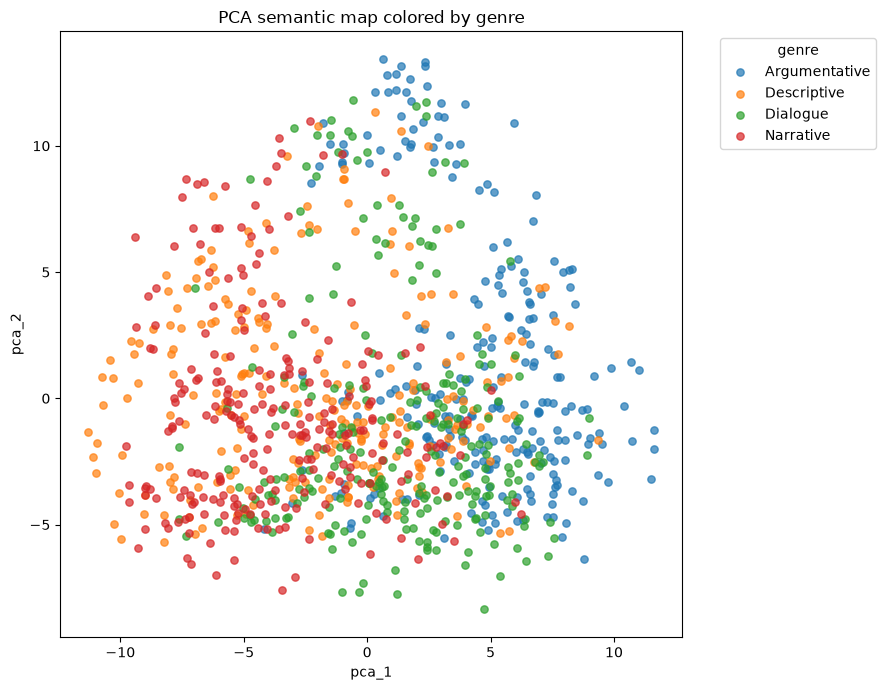

In [18]:
plot_2d_map(
    df=pca_df,
    x_col="pca_1",
    y_col="pca_2",
    color_col="genre",
    title="PCA semantic map colored by genre",
    output_filename="semantic_map_pca_genre.png",
)

### Interpretation: PCA by genre

The PCA map colored by genre shows more visible structure than the model-family PCA map, but the groups still overlap. Argumentative texts appear more concentrated toward the right and upper-right side of the plot, while descriptive and narrative texts appear more frequently on the left side. Dialogue texts are more dispersed through the central and lower regions.

This pattern suggests that genre affects the semantic embedding space more than model family does. That is reasonable because genre changes the type of discourse being produced: argumentative prompts encourage claims and reasoning, dialogue prompts encourage conversational exchange, descriptive prompts emphasize sensory or object-focused language, and narrative prompts emphasize events and story progression.

However, the separation is not clean. The genres still mix substantially in the central region, so I should not claim that PCA creates fully distinct genre clusters. The correct interpretation is that genre produces weak-to-moderate visual structure, but not strong separation.

Saved figure to: /Users/violaawor/Desktop/LLM-sytlometric/outputs/figures/semantic_map_pca_theme.png


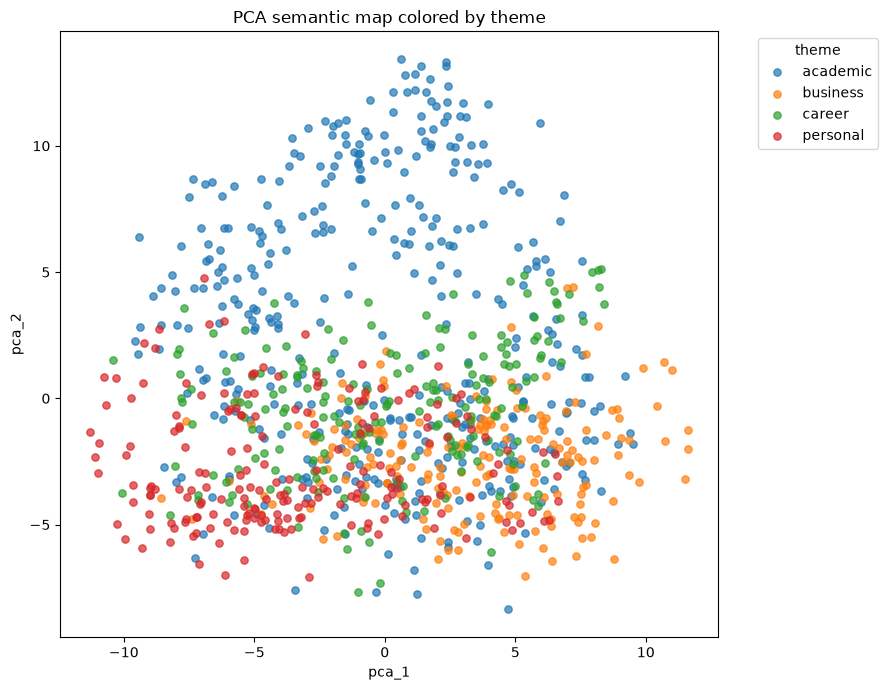

In [19]:
plot_2d_map(
    df=pca_df,
    x_col="pca_1",
    y_col="pca_2",
    color_col="theme",
    title="PCA semantic map colored by theme",
    output_filename="semantic_map_pca_theme.png",
)

### Interpretation: PCA by theme

The PCA map colored by theme shows the clearest visual organization among the PCA plots. Academic texts are more visible in the upper part of the plot, business texts are more concentrated toward the lower-right region, and personal texts appear more frequently toward the lower-left side. Career texts are more mixed, with many points occupying the central and right-central area.

This makes sense because theme is directly tied to semantic content. Academic, business, career, and personal prompts are likely to use different vocabularies and conceptual fields. Since sentence embeddings are designed to capture meaning, theme should influence the embedding coordinates more strongly than model family.

Even so, the plot still contains overlap across themes. Therefore, the correct conclusion is not that theme forms perfectly separated clusters, but that theme has the strongest visible semantic structure among the labels tested in this notebook.

## 5. t-SNE semantic maps

Next, I inspect t-SNE maps. Unlike PCA, t-SNE is nonlinear and is more sensitive to local neighborhood structure. It can reveal small clusters that may not be visible in PCA.

However, t-SNE should not be interpreted as a precise map of global distances. I use it here as a visual diagnostic, not as formal proof of separation.

Saved figure to: /Users/violaawor/Desktop/LLM-sytlometric/outputs/figures/semantic_map_tsne_model_family.png


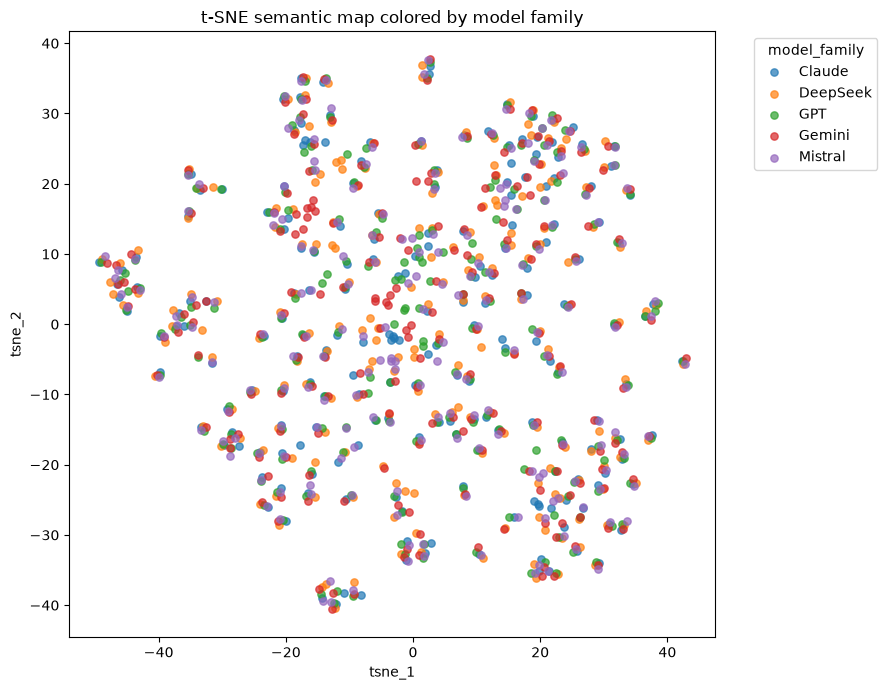

In [20]:
plot_2d_map(
    df=tsne_df,
    x_col="tsne_1",
    y_col="tsne_2",
    color_col="model_family",
    title="t-SNE semantic map colored by model family",
    output_filename="semantic_map_tsne_model_family.png",
)

### Interpretation: t-SNE by model family

The t-SNE map colored by model family confirms the PCA result. The small local clusters contain mixed colors from different model families rather than single-model groups. This is important because t-SNE is good at showing local neighborhoods: if model identity were semantically strong, I would expect local groups dominated by one model color.

Instead, the points from Claude, DeepSeek, GPT, Gemini, and Mistral are repeatedly co-located. This suggests that texts generated from the same or similar prompts are embedded near each other regardless of which model produced them.

I interpret the small t-SNE islands as prompt- or topic-level neighborhoods rather than model-family clusters. This supports the idea that the models are producing semantically similar responses to the same controlled prompt set.

Saved figure to: /Users/violaawor/Desktop/LLM-sytlometric/outputs/figures/semantic_map_tsne_genre.png


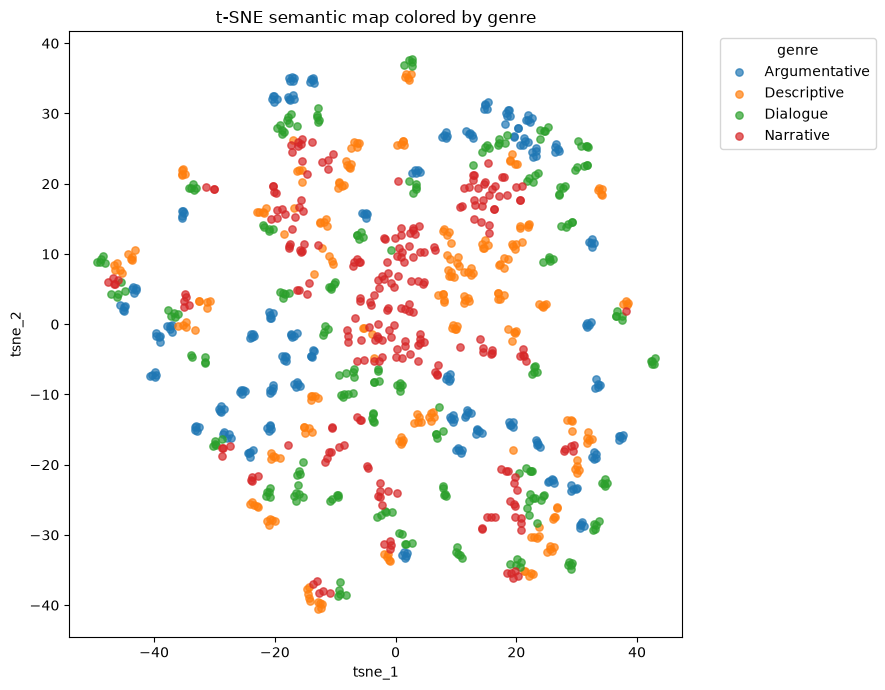

In [21]:
plot_2d_map(
    df=tsne_df,
    x_col="tsne_1",
    y_col="tsne_2",
    color_col="genre",
    title="t-SNE semantic map colored by genre",
    output_filename="semantic_map_tsne_genre.png",
)

### Interpretation: t-SNE by genre

The t-SNE map colored by genre shows some local genre patterns, but it is still not cleanly separated. Some regions contain more visible concentrations of one genre, while many other areas contain mixed genre colors.

Compared with the model-family t-SNE map, genre produces a more interpretable arrangement because genre changes the discourse form of the text. However, genre does not dominate the embedding space completely. This is likely because each genre includes multiple themes and topics, so semantic similarity is shared across genres.

The correct interpretation is that genre has a weak semantic signal. It influences local neighborhoods more than model family, but the overlap shows that genre alone does not produce sharply separated embedding clusters.

Saved figure to: /Users/violaawor/Desktop/LLM-sytlometric/outputs/figures/semantic_map_tsne_theme.png


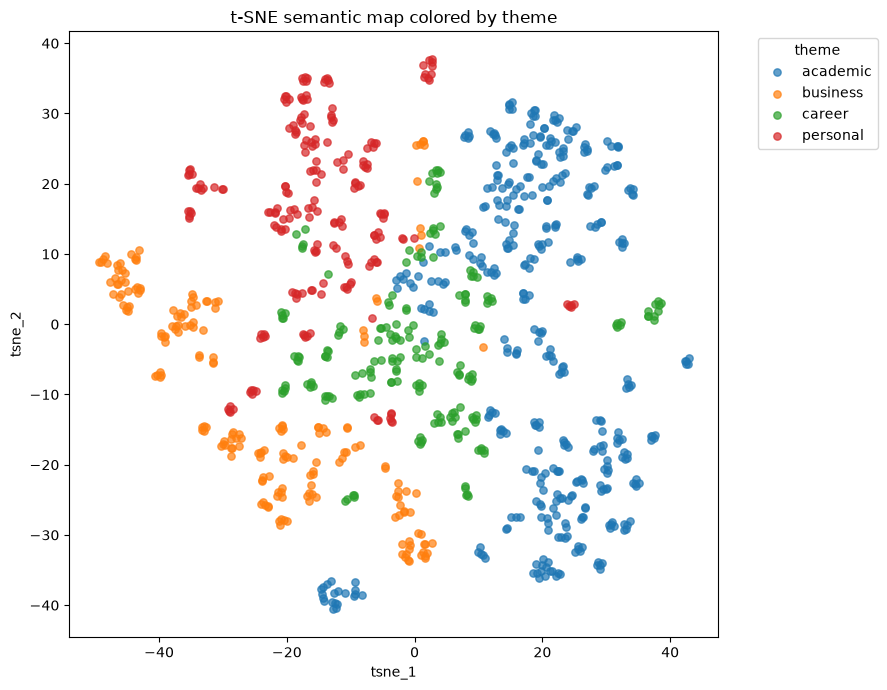

In [22]:
plot_2d_map(
    df=tsne_df,
    x_col="tsne_1",
    y_col="tsne_2",
    color_col="theme",
    title="t-SNE semantic map colored by theme",
    output_filename="semantic_map_tsne_theme.png",
)

### Interpretation: t-SNE by theme

The t-SNE map colored by theme shows the strongest visual grouping of the three t-SNE maps. Academic texts are concentrated more heavily on the right and upper-right regions, business texts appear more often on the left and lower-left regions, personal texts are more visible in the upper-left region, and career texts occupy many central areas.

This chart supports the silhouette result: theme is the label with the strongest semantic organization. This is expected because theme is closest to topic meaning, and sentence embeddings are built to capture semantic similarity.

However, the theme clusters are still not perfectly separated. There are mixed areas and transitional regions between themes. Therefore, I interpret the theme pattern as the strongest but still moderate visual structure in the semantic maps, not as a fully separable clustering result.

## 6. Silhouette score analysis

The silhouette scores provide a quantitative check of the visual maps. They help determine whether groups are actually clustered in embedding space rather than only appearing visually distinct.

,label,n_classes,silhouette_score_cosine
2,theme,4,0.068524
1,genre,4,0.036065
0,model_family,5,-0.007539


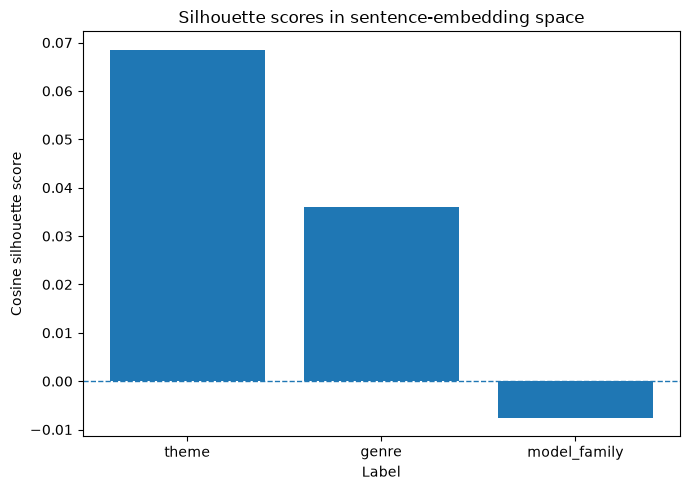

In [23]:
silhouette_df = silhouette_df.sort_values("silhouette_score_cosine", ascending=False)

display(silhouette_df)

plt.figure(figsize=(7, 5))
plt.bar(silhouette_df["label"], silhouette_df["silhouette_score_cosine"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Label")
plt.ylabel("Cosine silhouette score")
plt.title("Silhouette scores in sentence-embedding space")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "semantic_map_silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of silhouette scores

The silhouette scores provide the quantitative version of what the PCA and t-SNE maps show:

- `theme`: approximately `0.0685`
- `genre`: approximately `0.0361`
- `model_family`: approximately `-0.0075`

All three values are close to zero, which means that none of the labels forms strong clusters in sentence-embedding space. However, the ranking is meaningful. Theme has the highest score, genre has a smaller positive score, and model family has a slightly negative score.

The negative model-family silhouette score means that texts from the same model family are not closer to each other than they are to texts from other model families. In other words, model identity is not naturally clustered in this embedding space.

The chart therefore supports a clear conclusion: sentence embeddings capture prompt content and theme more than they capture model-specific writing identity. This is why theme appears highest in the bar chart, while model family falls slightly below zero.

## 7. Comparison with stylometric analysis

The semantic mapping results are different from the stylometric results.

The semantic maps show weak clustering by model family. In both PCA and t-SNE, the five model-family colors are highly mixed. The silhouette score for `model_family` is approximately `-0.0075`, which confirms that there is almost no model-family separation in general sentence-embedding space.

However, the stylometric feature analysis showed visible and measurable differences in writing form, including sentence length, punctuation, lexical richness, function-word usage, readability, and marker usage. This creates an important contrast: the models are semantically similar because they answer the same prompts, but they may still differ in how they express those answers.

This distinction is central to my project. Semantic embeddings mainly capture what the texts are about. Stylometric features capture how the texts are written. The weak model-family clustering in semantic maps therefore strengthens the motivation for stylometric fingerprinting rather than weakening the project.

In [24]:
silhouette_df.to_csv(TABLE_DIR / "notebook_06_silhouette_scores.csv", index=False)

semantic_summary = pd.DataFrame({
    "finding": [
        "Embedding rows",
        "Embedding dimensions",
        "Highest silhouette label",
        "Highest silhouette score",
        "Model-family silhouette score",
        "Main interpretation",
    ],
    "value": [
        embeddings.shape[0],
        embeddings.shape[1],
        silhouette_df.iloc[0]["label"],
        silhouette_df.iloc[0]["silhouette_score_cosine"],
        silhouette_df.loc[
            silhouette_df["label"] == "model_family",
            "silhouette_score_cosine"
        ].iloc[0],
        "Semantic embeddings show weak model-family clustering; theme shows the strongest but still weak structure.",
    ],
})

semantic_summary.to_csv(TABLE_DIR / "notebook_06_semantic_summary.csv", index=False)

display(semantic_summary)

print("Saved semantic summary tables to:", TABLE_DIR)

,finding,value
0,Embedding rows,1000
1,Embedding dimensions,384
2,Highest silhouette label,theme
3,Highest silhouette score,0.068524
4,Model-family silhouette score,-0.007539
5,Main interpretation,Semantic embeddings show weak model-family clu...


Saved semantic summary tables to: /Users/violaawor/Desktop/LLM-sytlometric/outputs/tables


## 8. Semantic mapping conclusion

In this notebook, I used sentence embeddings, PCA, t-SNE, and silhouette scores to examine whether LLM-generated texts cluster by model family, genre, or theme.

The main result is that model family does not form strong clusters in semantic embedding space. In the PCA map colored by model family, the five LLM families overlap heavily. In the t-SNE map, local neighborhoods also contain mixed model colors rather than separate model-specific islands. The model-family silhouette score is slightly negative at approximately `-0.0075`, confirming that model identity is not naturally separated in this embedding representation.

Theme shows the strongest semantic structure. In both PCA and t-SNE, theme produces the clearest visual grouping, and it also has the highest silhouette score at approximately `0.0685`. This is expected because theme is directly related to topic content. Genre shows weaker but still positive structure, with a silhouette score of approximately `0.0361`.

The overall conclusion is that general-purpose sentence embeddings organize the generated texts more by semantic content than by model identity. This does not mean the models write identically. Instead, it means that when all models answer the same controlled prompts, their outputs are semantically similar enough that model-family differences are not strongly visible in embedding space.

This result strengthens the logic of the project. Semantic maps show weak model-family separation, while the stylometric analysis shows stronger model-family differences in writing form. Therefore, the evidence suggests that LLM fingerprinting is more visible through stylometric features than through broad semantic-content embeddings.

The next phase should formally test the stylometric features across model families using statistical tests and multiple-comparison correction.